In [1]:
import pandas as pd
from gseapy.plot import gseaplot
import gseapy as gp
import numpy as np

In [77]:
df = pd.read_excel(r"E:\KCL\scRNAseq\scRNAseq\mouse\GSM6160615_adata\phd thesis\de_gamma_cell_type.xlsx", sheet_name='Sheet1')

In [78]:
df

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,Mrpl15,17.758560,-0.289710,0.398693,-0.726650,0.467440,NaN
1,Lypla1,12.952562,0.389879,0.467599,0.833789,0.404400,NaN
2,Tcea1,21.641713,0.029348,0.367227,0.079918,0.936302,NaN
3,Atp6v1h,20.789611,-0.006848,0.372826,-0.018368,0.985345,NaN
4,Rb1cc1,15.048534,1.024175,0.432172,2.369833,0.017796,NaN
...,...,...,...,...,...,...,...
10168,mt-Nd6,2.240167,0.065995,1.124185,0.058705,0.953187,NaN
10169,mt-Cytb,1563.044181,-0.082066,0.093102,-0.881472,0.378062,0.581602
10170,Vamp7,23.479635,-0.230076,0.348814,-0.659597,0.509513,NaN
10171,PISD,41.985700,0.498469,0.271220,1.837875,0.066081,NaN


In [79]:
df = df.rename(columns= {'Unnamed: 0': 'Gene'})

In [80]:
df = df.dropna()
df['Gene'] = df['Gene'].str.upper()

In [81]:
df

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
16,TRAM1,69.569766,-0.262549,0.211980,-1.238555,2.155102e-01,4.208717e-01
20,RPL7,682.696557,-0.204179,0.094505,-2.160514,3.073290e-02,1.190478e-01
23,TCEB1,76.132433,-0.067228,0.202170,-0.332534,7.394863e-01,8.617154e-01
56,COX5B,176.161470,-0.239741,0.150437,-1.593636,1.110177e-01,2.812454e-01
72,RPL31,804.312927,0.068745,0.100033,0.687219,4.919450e-01,6.813776e-01
...,...,...,...,...,...,...,...
10163,MT-CO3,3733.253067,0.001411,0.093199,0.015141,9.879196e-01,9.970157e-01
10164,MT-ND3,210.679260,0.904212,0.138231,6.541317,6.097952e-11,5.373820e-09
10166,MT-ND4,980.453982,0.191890,0.105294,1.822423,6.839080e-02,2.069335e-01
10167,MT-ND5,84.400156,0.600470,0.201686,2.977257,2.908404e-03,2.412264e-02


In [82]:
df = df[df['padj']>0]

In [83]:
df

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
16,TRAM1,69.569766,-0.262549,0.211980,-1.238555,2.155102e-01,4.208717e-01
20,RPL7,682.696557,-0.204179,0.094505,-2.160514,3.073290e-02,1.190478e-01
23,TCEB1,76.132433,-0.067228,0.202170,-0.332534,7.394863e-01,8.617154e-01
56,COX5B,176.161470,-0.239741,0.150437,-1.593636,1.110177e-01,2.812454e-01
72,RPL31,804.312927,0.068745,0.100033,0.687219,4.919450e-01,6.813776e-01
...,...,...,...,...,...,...,...
10163,MT-CO3,3733.253067,0.001411,0.093199,0.015141,9.879196e-01,9.970157e-01
10164,MT-ND3,210.679260,0.904212,0.138231,6.541317,6.097952e-11,5.373820e-09
10166,MT-ND4,980.453982,0.191890,0.105294,1.822423,6.839080e-02,2.069335e-01
10167,MT-ND5,84.400156,0.600470,0.201686,2.977257,2.908404e-03,2.412264e-02


In [84]:
df['Rank'] = -np.log10(df.padj) * df.log2FoldChange

df = df.sort_values('Rank', ascending= False).reset_index(drop = True)

In [85]:
df['Rank']

0      118.129445
1       29.482416
2       24.965888
3       21.415639
4       10.316021
          ...    
700     -3.852911
701     -3.988287
702     -4.029490
703    -19.446420
704    -75.769245
Name: Rank, Length: 705, dtype: float64

In [86]:
ranking = df[['Gene', 'Rank']]

In [87]:
ranking

,Gene,Rank
0,FOSB,118.129445
1,KRT8,29.482416
2,FOS,24.965888
3,EGR1,21.415639
4,JUN,10.316021
...,...,...
700,RBP4,-3.852911
701,SSR4,-3.988287
702,INS2,-4.029490
703,CD63,-19.446420


In [88]:
#pre_res = gp.prerank(rnk= ranking, gene_sets='MSigDB_Hallmark_2020', seed = 10)

pre_res = gp.prerank(rnk= ranking, gene_sets='GO_Biological_Process_2023', seed = 10)

In [89]:
KEGG_2019_dict = pre_res.results

In [90]:
out = []

for term in list(KEGG_2019_dict):
    out.append([term,
                KEGG_2019_dict[term]['pval'],
                KEGG_2019_dict[term]['fdr'],
                KEGG_2019_dict[term]['es'],
                KEGG_2019_dict[term]['nes']
               ]
    )

out_df = pd.DataFrame(out, columns= ['Term', 'pval', 'fdr', 'es', 'nes']).sort_values('fdr').reset_index(drop = True)

In [91]:
out_df.to_excel('gamma_cell_GO_Biological_Process_2023.xlsx')

In [92]:
term_to_graph = out_df.iloc[0].Term
term_to_graph

'Negative Regulation Of Transcription By RNA Polymerase II (GO:0000122)'

[<Axes: xlabel='Gene Rank', ylabel='Ranked metric'>,
 <Axes: >,
 <Axes: >,
 <Axes: ylabel='Enrichment Score'>]

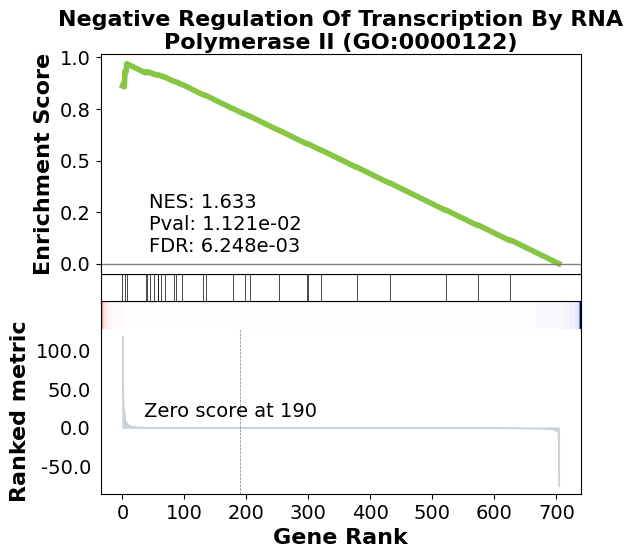

In [93]:
gseaplot(
    rank_metric=pre_res.ranking, 
    term="Negative Regulation Of Transcription By RNA Polymerase II (GO:0000122)", 
    **pre_res.results["Negative Regulation Of Transcription By RNA Polymerase II (GO:0000122)"]
)

In [69]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMap_CRISPR_GeneDependency_CellLines_2023',
 'DepMap_WG_CRISPR_Screens_Broad_CellLines_2019',
 'DepMap_WG_CRISPR_Screens_Sanger_Cell